# Slight Overcharge Fault Detection and Physics-Informed Isolation

This notebook implements the unsupervised deep learning framework described in : "Lithium-Ion Batteries Slight Overcharge Fault Detection and Physics-Informed Isolation Using Unsupervised Deep-Learning".

The process is as follows:
1.  **Setup:** Import libraries and define helper functions.
2.  **Data Loading & Preprocessing:** Load experimental data and normalize the temperature profiles.
3.  **Model Architecture:** Define the 1D-CNN Autoencoder with residual blocks and attention.
4.  **Model Training / Loading:** Train the model (optional) or load the pre-trained model used for the paper.
5.  **Model Evaluation (Visual & RE):** Plot example reconstructions and calculate the baseline Mean Squared Error for each dataset.
6.  **Anomaly Detection (Robust Threshold Selection):** Implement the procedure from Section 5.1.1 to find the optimal, noise-resistant anomaly detection threshold.
7.  **Fault Isolation (Physics-Informed):** Implement the physics-informed OCD metric (Section 4.3) to isolate the overcharge fault from other anomalies.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import importlib
import BatteryDataToolkit
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import Callback
from tensorflow.keras import layers
from tensorflow import keras
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support, precision_score, recall_score
import pandas as pd
import seaborn as sns
from scipy.signal import savgol_filter
import plotly.express as px
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

def reloader_init():
    importlib.reload(BatteryDataToolkit)
    return BatteryDataToolkit.DataInitializer

def reloader_vis():
    importlib.reload(BatteryDataToolkit)
    return BatteryDataToolkit.DataVisualizer

### Plotting Callback
A simple Keras callback to plot training and validation loss live during fitting.

In [2]:
class PlotLosses(Callback):
    def on_train_begin(self, logs={}):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.fig = plt.figure()

        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.i += 1

        clear_output(wait=True)
        plt.plot(self.x, self.losses, label="Train loss")
        plt.plot(self.x, self.val_losses, label="Validation loss")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Losses')
        plt.grid()
        plt.legend()
        plt.show()

plot_losses = PlotLosses()

## 2. Data Loading & Preprocessing

Data is loaded using the custom `BatteryDataToolkit`.

In [ ]:
Conditions = ['V42-B', 'V42-C', 'V435-B', 'V45-A', 'V45-B', 'V42-B-LT', 'V42-B-HT', 'OD1', 'OD2']

Initializer = reloader_init()(cutoff=0.1, fs=4, order=4, window_size_f1=80, window_size_f2=2, SG_order1=5, SG_order2=1, C_init=2.5)
data_dict = {Condition: Initializer.load_Experimental(f'./Experimental/{Condition}.csv') for Condition in Conditions}

V42 = data_dict['V42-B']     # Healthy (Training)
V42V = data_dict['V42-C']    # Healthy (Validation)
V435 = data_dict['V435-B']   # Slight Overcharge (4.35V)
V45A = data_dict['V45-A']    # Slight Overcharge (4.50V)
V45B = data_dict['V45-B']    # Slight Overcharge (4.50V)
LT = data_dict['V42-B-LT']   # Low Temperature Fault
HT = data_dict['V42-B-HT']   # High Temperature Fault
OD1 = data_dict['OD1']       # Over-discharge Fault (Set 1)
OD2 = data_dict['OD2']       # Over-discharge Fault (Set 2)


### Data Normalization and Splitting

The data is processed according to **Section 4.1**:
1.  `measurement = 'Temperature'`: We select the temperature profile.
2.  `label = 'Equalized_dch'`: This likely refers to the time-equalized discharge profile (L=96) mentioned in the paper.
3.  `normalize(data)`: A per-cycle min-max normalization is applied.
4.  `train_loader(...)`: This function selects the cycles and applies the normalization.
5.  **Splitting Strategy:** The data is split by cell, which is a robust method.
    * **Training Set (`X_train`):** Healthy cell `V42`.
    * **Validation Set (`X_valid`):** Healthy cell `V42V`. Used for threshold selection.
    * **Anomaly/Test Sets:** All other fault condition cells.

In [15]:
measurement = 'Temperature'
label = 'Equalized_dch'

def normalize(data):
    
    data = np.array(data)
    data_min = np.min(data)
    data_max = np.max(data)
    
    if data_max - data_min == 0:
        return np.zeros_like(data)
    
    normalized_data = (data - data_min) / (data_max - data_min)
    return np.array(normalized_data)

def train_loader (data, end_cycle, label, measurement):
    cycles = np.array(data['cycles'])
    all_measurements = data[label][measurement]
    mask = cycles < end_cycle
    return np.array([normalize(all_measurements[i]) for i in range(len(cycles)) if mask[i]])

healthy_data = train_loader(V42, 300, label, measurement)
healthy_data_V = train_loader(V42V, 300, label, measurement)
anomaly_data_435 = train_loader(V435, 140, label, measurement)
anomaly_data_450_A = train_loader(V45A, 138, label, measurement)
anomaly_data_450_B = train_loader(V45B, 129, label, measurement)
anomaly_data_450 = np.concatenate([anomaly_data_450_A, anomaly_data_450_B], axis=0)

X_train = healthy_data[..., np.newaxis]
X_valid = healthy_data_V[..., np.newaxis]
X_anomaly_435 = anomaly_data_435[..., np.newaxis]
X_anomaly_450_A = anomaly_data_450_A[..., np.newaxis]
X_anomaly_450_B = anomaly_data_450_B[..., np.newaxis]
X_anomaly_450 = anomaly_data_450[..., np.newaxis]

In [8]:
X_low_temp_fault = np.array([normalize(cycle) for cycle in LT[label][measurement]])
X_low_temp_fault = X_low_temp_fault[..., np.newaxis]

X_high_temp_fault = np.array([normalize(cycle) for cycle in HT[label][measurement]])
X_high_temp_fault = X_high_temp_fault[..., np.newaxis]

X_overdischarge_fault1 = np.array([normalize(cycle) for cycle in OD1[label][measurement]])
X_overdischarge_fault2 = np.array([normalize(cycle) for cycle in OD2[label][measurement]])
X_overdischarge_fault = np.concatenate([X_overdischarge_fault1, X_overdischarge_fault2], axis=0)
X_overdischarge_fault = X_overdischarge_fault[..., np.newaxis]

## 3. Model Architecture (1D-CNN-AE)

This defines the 1D Convolutional Autoencoder architecture as described in **Section 4.2** and **Figure 4** of the paper.

It features:
-   A symmetric Encoder-Decoder structure.
-   Strided convolutions for downsampling (instead of Pooling) to retain temporal information.
-   Transposed convolutions for upsampling.
-   Residual blocks (`residual_block`) to aid training.
-   An Attention mechanism (`attention_block`) in the latent space.

In [10]:
def residual_block(x, filters, kernel_size):
    shortcut = x
    x = layers.Conv1D(filters=filters, kernel_size=kernel_size, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)  
    
    x = layers.Conv1D(filters=filters, kernel_size=kernel_size, padding="same", activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)  
    
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

def attention_block(x):
    attention = layers.Conv1D(filters=1, kernel_size=1, padding="same", activation="sigmoid")(x)
    return layers.Multiply()([x, attention])

dropout_rate = 0.2
inputs = layers.Input(shape=(X_train.shape[1], X_train.shape[2]))

# ----- ENCODER -----
x = layers.Conv1D(filters=64, kernel_size=7, padding="same", strides=2, activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(dropout_rate)(x) 
x = residual_block(x, filters=64, kernel_size=7)

x = layers.Conv1D(filters=128, kernel_size=5, padding="same", strides=2, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(dropout_rate)(x) 
x = residual_block(x, filters=128, kernel_size=5)

x = layers.Conv1D(filters=256, kernel_size=3, padding="same", strides=2, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(dropout_rate)(x) 
x = residual_block(x, filters=256, kernel_size=3)

# ----- LATENT SPACE -----
x = attention_block(x)
latent_code = layers.Conv1D(filters=2, kernel_size=1, padding="same", activation="relu")(x)

# ----- DECODER -----
x = layers.Conv1DTranspose(filters=256, kernel_size=3, padding="same", strides=2, activation="relu")(latent_code)
x = layers.BatchNormalization()(x)
x = layers.Dropout(dropout_rate)(x)
x = residual_block(x, filters=256, kernel_size=3)

x = layers.Conv1DTranspose(filters=128, kernel_size=5, padding="same", strides=2, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(dropout_rate)(x) 
x = residual_block(x, filters=128, kernel_size=5)

x = layers.Conv1DTranspose(filters=64, kernel_size=7, padding="same", strides=2, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(dropout_rate)(x) 
x = residual_block(x, filters=64, kernel_size=7)

x = layers.Conv1DTranspose(filters=1, kernel_size=7, padding="same")(x)
outputs = x

# ----- MODEL CREATION -----
model_base = keras.Model(inputs, outputs, name='base_model')
model_latent= keras.Model(inputs, latent_code, name='latent_model')

model_base.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

model_base.summary()


Model: "base_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 48, 64)    │        512 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 64)    │        256 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 48, 64)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 48, 64)    │     28,736 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 64)    │        256 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 48, 64)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 48, 64)    │     28,736 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 64)    │        256 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 48, 64)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 48, 64)    │          0 │ dropout_20[0][0], │
│                     │                   │            │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 48, 64)    │          0 │ add_6[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 24, 128)   │     41,088 │ activation_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 128)   │        512 │ conv1d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 24, 128)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 24, 128)   │     82,048 │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 128)   │        512 │ conv1d_21[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 24, 128)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,605,892 (6.13 MB)

 Trainable params: 1,600,516 (6.11 MB)

 Non-trainable params: 5,376 (21.00 KB)

## 4. Model Training (Optional)

The following cell can be run to train the model from scratch on the `X_train` (V42) dataset. 

**Note:** The cell after this one loads a pre-trained model, which was used to generate the results in the paper. Skip this cell if you wish to use the pre-trained model.

In [ ]:
history = model_base.fit(
    X_train,
    X_train,
    epochs=3000,
    batch_size=64,
    shuffle=True,
    validation_split=0.1,
    callbacks=[plot_losses],
) 


### Save Model (Optional)

If you trained a new model, run the cell below to save it.

In [ ]:
import datetime
import os

now = datetime.datetime.now()
timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")

model_name = f"model_base{timestamp}.keras"
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, model_name)
model_base.save(save_path)

print(f"Model saved to: {save_path}")

## 5. Load Pre-trained Model & Initial Evaluation

In [12]:
model_path = "saved_models/model_base_2025-07-17_15-14-19.keras"
model_base = load_model(model_path)
model_base.summary()

Model: "base_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 96, 64)    │        512 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 64)    │        256 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 48, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 48, 64)    │     28,736 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 64)    │        256 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 48, 64)    │     28,736 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 64)    │        256 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 48, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 48, 64)    │          0 │ add_6[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 48, 128)   │     41,088 │ activation_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 128)   │        512 │ conv1d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 24, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 24, 128)   │     82,048 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 128)   │        512 │ conv1d_21[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 24, 128)   │     82,048 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 128)   │        512 │ conv1d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 24, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 24, 128)   │          0 │ add_7[0][0]     

 Total params: 3,206,410 (12.23 MB)

 Trainable params: 1,600,516 (6.11 MB)

 Non-trainable params: 5,376 (21.00 KB)

 Optimizer params: 1,600,518 (6.11 MB)

### Quantitative Evaluation: Reconstruction Error

This cell calculates the mean reconstruction error (MSE) for each dataset, corresponding to **Table 5** in the paper. As expected, the healthy training and validation errors are low, while all fault conditions have significantly higher errors.

In [14]:
print("\n--- Reconstruction Errors ---")
reconstructed_healthy = model_base.predict(X_train)
reconstructed_anomaly_435 = model_base.predict(X_anomaly_435)
reconstructed_anomaly_450_A = model_base.predict(X_anomaly_450_A)
reconstructed_anomaly_450_B = model_base.predict(X_anomaly_450_B)
reconstructed_anomaly_450 = model_base.predict(X_anomaly_450)

reconstructed_healthy_V = model_base.predict(X_valid)
reconstructed_LT = model_base.predict(X_low_temp_fault)
reconstructed_HT = model_base.predict(X_high_temp_fault)
reconstructed_OD = model_base.predict(X_overdischarge_fault)

def calculate_reconstruction_error(original, reconstructed):
    return np.mean(np.square(original - reconstructed))

error_healthy = calculate_reconstruction_error(X_train, reconstructed_healthy)
error_anomaly_435 = calculate_reconstruction_error(X_anomaly_435, reconstructed_anomaly_435)
error_anomaly_450 = calculate_reconstruction_error(X_anomaly_450, reconstructed_anomaly_450)

error_healthy_V = calculate_reconstruction_error(X_valid, reconstructed_healthy_V)
error_LT = calculate_reconstruction_error(X_low_temp_fault, reconstructed_LT)
error_HT = calculate_reconstruction_error(X_high_temp_fault, reconstructed_HT)
error_OD = calculate_reconstruction_error(X_overdischarge_fault, reconstructed_OD)

print(f"Healthy error: {np.mean(error_healthy):.6f}")
print(f"Healthy (validation) error: {np.mean(error_healthy_V):.6f}")
print(f"V435 error: {np.mean(error_anomaly_435):.6f}")
print(f"V45 error: {np.mean(error_anomaly_450):.6f}")
print(f"Low Temp error: {np.mean(error_LT):.6f}")
print(f"High Temp error: {np.mean(error_HT):.6f}")
print(f"Over Discharge error: {np.mean(error_OD):.6f}")



--- Reconstruction Errors ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Healthy error: 0.002876
Healthy (validation) error: 0.001438
V435 error: 0.003229
V45 error: 0.004733
Low Temp error: 0.019604
High Temp error: 0.008784
Over Discharge error: 0.012540


### Visual Evaluation: Reconstructions

Plotting a few examples (as in Figure 5) to visually confirm the autoencoder's performance. The model should reconstruct healthy profiles well (low error) and struggle with faulty profiles (high error).

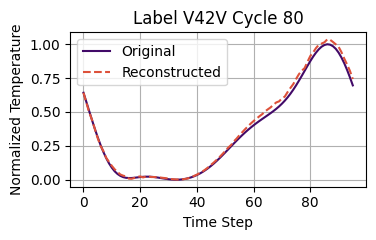

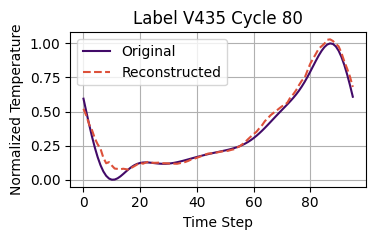

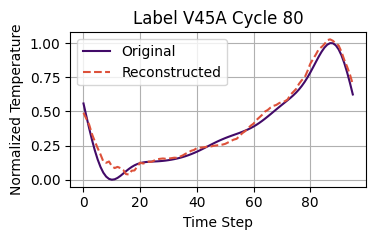

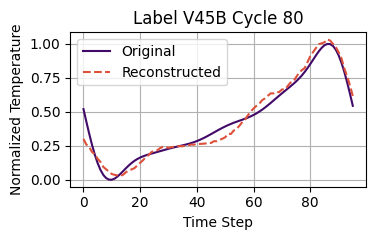

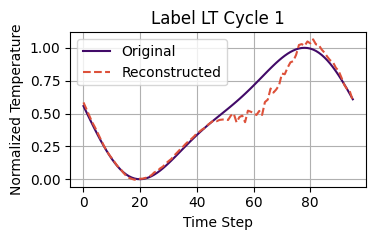

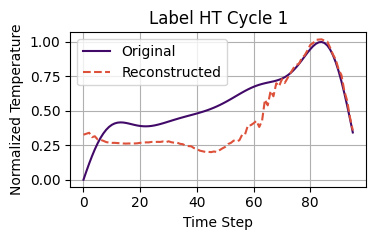

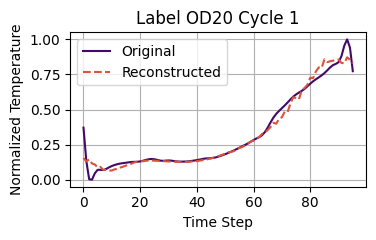

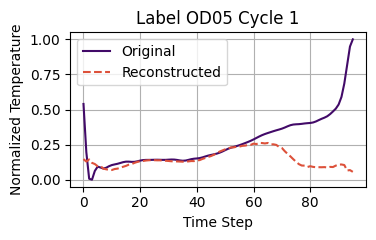

In [ ]:
colors = plt.cm.inferno(np.linspace(0.2, 0.6, 2))

def plot_reconstructions_same_plot(original_data,reconstruction_data, title, n_samples=5, indices=None):
    # Randomly choose sample indices
    if indices:
        samples = original_data[indices]
        n_samples = len(indices)
    else:
        indices = np.random.choice(len(original_data), n_samples, replace=False)
        samples = original_data[indices]

    # Get reconstructions
    reconstructions = reconstruction_data[indices]

    # Plot
    plt.figure(figsize=(10, n_samples * 2.5))
    for i in range(n_samples):
        plt.subplot(n_samples, 3, i + 1)
        plt.plot(samples[i].squeeze(), label='Original', color=colors[0])
        plt.plot(reconstructions[i].squeeze(), label='Reconstructed', color=colors[1], linestyle='--')
        if title == "OD20" or title == "OD05":
            plt.title(f'Label {title} Cycle 1')
        else:
            plt.title(f'Label {title} Cycle {indices[i]}')
        plt.grid(True)
        plt.legend(loc='upper left')
        plt.xlabel('Time Step')
        plt.ylabel('Normalized Temperature')

    plt.tight_layout()
    plt.show()


plot_reconstructions_same_plot(X_train, reconstructed_healthy, title="V42V",  indices=[80])
plot_reconstructions_same_plot(X_anomaly_435,reconstructed_anomaly_435, title="V435",  indices=[80])
plot_reconstructions_same_plot(X_anomaly_450_A,reconstructed_anomaly_450_A, title="V45A",  indices=[80])
plot_reconstructions_same_plot(X_anomaly_450_B,reconstructed_anomaly_450_B, title="V45B",  indices=[80])
plot_reconstructions_same_plot(X_low_temp_fault,reconstructed_LT, title="LT",  indices=[1])
plot_reconstructions_same_plot(X_high_temp_fault,reconstructed_HT, title="HT",  indices=[1])
plot_reconstructions_same_plot(X_overdischarge_fault,reconstructed_OD, title="OD20",  indices=[1])
plot_reconstructions_same_plot(X_overdischarge_fault,reconstructed_OD, title="OD05",  indices=[37])

## 6. Anomaly Detection: Robust Threshold Selection

This section implements the full methodology from **Section 5.1** of the paper.

1.  `find_globally_robust_threshold`: This function (from paper Sec 5.1.1) finds the best threshold. It tests multiple noise levels on the **training data (`X_train`)** and all fault types to find a threshold that is robust to noise.
2.  `validate_robust_threshold`: This function (from paper Sec 5.1.2) validates the chosen threshold on the **held-out validation data (`X_valid`)** and all fault types to ensure generalization. This generates the results shown in Table 4.

In [ ]:
SG_WINDOW = 50
SG_ORDER = 5

def filter_sg(data, window_size=SG_WINDOW, sg_order=SG_ORDER):
    if len(data) >= window_size:
        return savgol_filter(data, window_size, sg_order, axis=0)
    else:
        return data

def apply_filter_pipeline(dataset):
    filtered_dataset = np.copy(dataset)
    for i in range(dataset.shape[0]):
        sample_ts = dataset[i, :, 0]
        sample_ts = filter_sg(sample_ts)
        filtered_dataset[i, :, 0] = sample_ts
    return filtered_dataset

Consolidating all fault types into a single anomaly dataset...
Shape of the consolidated anomaly dataset: (493, 96, 1)

===== Analyzing Noise Level: 0.0 =====
Local Best Threshold: 0.000878 (with F1-Score: 0.9847)

===== Analyzing Noise Level: 0.01 =====
Local Best Threshold: 0.000907 (with F1-Score: 0.9847)

===== Analyzing Noise Level: 0.03 =====
Local Best Threshold: 0.001023 (with F1-Score: 0.9774)

===== Analyzing Noise Level: 0.05 =====
Local Best Threshold: 0.000961 (with F1-Score: 0.9704)

--- Step 2: Creating Performance Matrices with Unique Candidate Thresholds ---
Unique Candidate Thresholds: ['0.000878', '0.000907', '0.000961', '0.001023']

--- F1-Score Performance Matrix ---
              0.00      0.01      0.03      0.05
0.000878  0.984741  0.984741  0.976744  0.953786
0.000907  0.985743  0.984709   0.97665  0.963037
0.000961  0.986748  0.985714  0.980553  0.970438
0.001023   0.98364  0.981557  0.977413  0.969136

--- Accuracy Performance Matrix ---
              0.00   

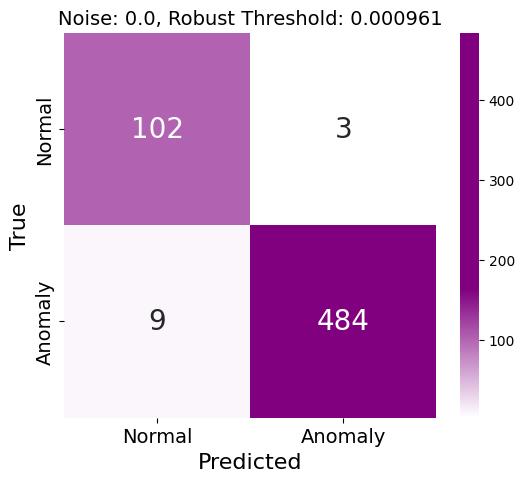

Applying filters to validation data for noise level 0.01...

--- Performance for: Noise: 0.01, Robust Threshold: 0.000961 ---
Accuracy:  0.9766
Precision: 0.9898
Recall:    0.9817
F1-Score:  0.9857

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.95      0.93       105
     Anomaly       0.99      0.98      0.99       493

    accuracy                           0.98       598
   macro avg       0.95      0.97      0.96       598
weighted avg       0.98      0.98      0.98       598



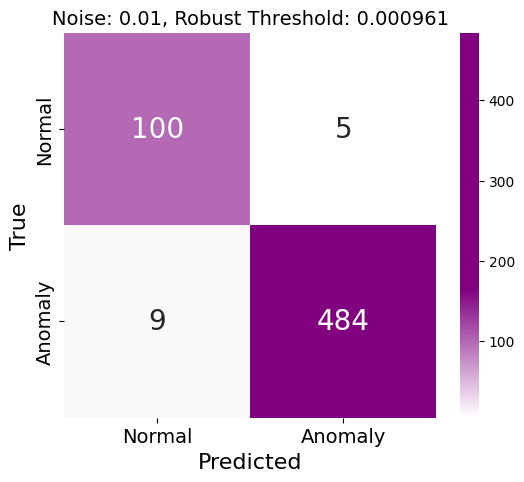

Applying filters to validation data for noise level 0.03...

--- Performance for: Noise: 0.03, Robust Threshold: 0.000961 ---
Accuracy:  0.9649
Precision: 0.9797
Recall:    0.9777
F1-Score:  0.9787

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.90      0.90       105
     Anomaly       0.98      0.98      0.98       493

    accuracy                           0.96       598
   macro avg       0.94      0.94      0.94       598
weighted avg       0.97      0.96      0.96       598



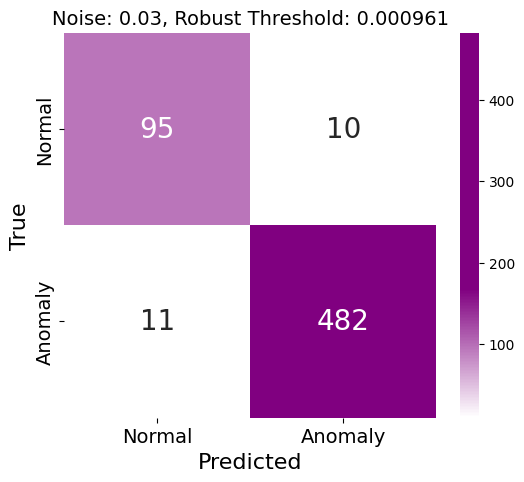

Applying filters to validation data for noise level 0.05...

--- Performance for: Noise: 0.05, Robust Threshold: 0.000961 ---
Accuracy:  0.9448
Precision: 0.9675
Recall:    0.9655
F1-Score:  0.9665

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.85      0.84       105
     Anomaly       0.97      0.97      0.97       493

    accuracy                           0.94       598
   macro avg       0.90      0.91      0.91       598
weighted avg       0.95      0.94      0.94       598



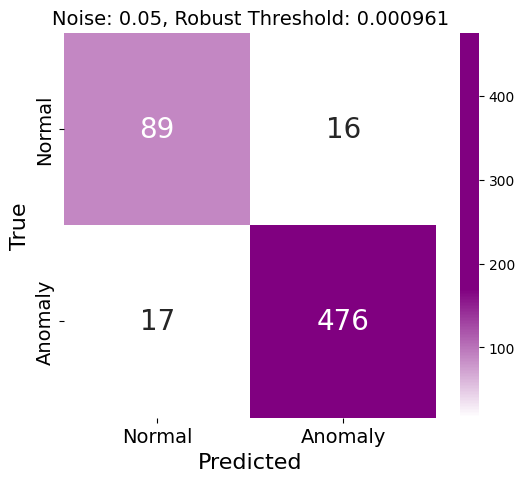

In [ ]:
cmap = LinearSegmentedColormap.from_list(
    'purple_white_purple', ['white', 'purple','purple',  'purple'])

def print_and_plot_performance(y_true, y_pred, title):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n--- Performance for: {title} ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'], zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=['Normal', 'Anomaly'],
        yticklabels=['Normal', 'Anomaly'],
        annot_kws={"size": 20}
    )
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel('Predicted', fontsize=16)
    plt.ylabel('True', fontsize=16)
    plt.title(title, fontsize=14)
    plt.show()

def find_globally_robust_threshold(model, X_normal_train, X_anomaly, noise_levels):
    candidate_thresholds = []
    noisy_datasets = {}

    for noise in noise_levels:
        print(f"\n===== Analyzing Noise Level: {noise} =====")
        X_normal_noisy = X_normal_train + np.random.normal(0, noise, X_normal_train.shape)
        X_anomaly_noisy = X_anomaly + np.random.normal(0, noise, X_anomaly.shape)
        
        X_normal_filtered = apply_filter_pipeline(X_normal_noisy)
        X_anomaly_filtered = apply_filter_pipeline(X_anomaly_noisy)
        
        recon_normal = model.predict(X_normal_filtered, verbose=0)
        errors_normal = np.mean(np.square(X_normal_filtered - recon_normal), axis=(1,2))
        
        recon_anomaly = model.predict(X_anomaly_filtered, verbose=0)
        errors_anomaly = np.mean(np.square(X_anomaly_filtered - recon_anomaly), axis=(1,2))
        noisy_datasets[noise] = {'errors_normal': errors_normal, 'errors_anomaly': errors_anomaly}

        y_true = np.concatenate([np.zeros(len(errors_normal)), np.ones(len(errors_anomaly))])
        all_errors = np.concatenate([errors_normal, errors_anomaly])
        
        best_f1 = 0
        local_best_threshold = 0
        threshold_candidates_local = np.linspace(np.min(all_errors), np.max(all_errors), 500)

        for t in threshold_candidates_local:
            y_pred = (all_errors > t).astype(int)
            f1 = f1_score(y_true, y_pred)
            if f1 > best_f1:
                best_f1 = f1
                local_best_threshold = t
        
        candidate_thresholds.append(local_best_threshold)
        print(f"Local Best Threshold: {local_best_threshold:.6f} (with F1-Score: {best_f1:.4f})")

    candidate_thresholds = sorted(list(set(candidate_thresholds)))
    print(f"\n--- Step 2: Creating Performance Matrices with Unique Candidate Thresholds ---")
    print(f"Unique Candidate Thresholds: {[f'{t:.6f}' for t in candidate_thresholds]}")

    f1_matrix = pd.DataFrame(index=[f"{t:.6f}" for t in candidate_thresholds], columns=noise_levels)
    accuracy_matrix = pd.DataFrame(index=f1_matrix.index, columns=noise_levels)
    precision_matrix = pd.DataFrame(index=f1_matrix.index, columns=noise_levels)
    recall_matrix = pd.DataFrame(index=f1_matrix.index, columns=noise_levels)

    for threshold in candidate_thresholds:
        for noise in noise_levels:
            errors_normal = noisy_datasets[noise]['errors_normal']
            errors_anomaly = noisy_datasets[noise]['errors_anomaly']
            
            y_true = np.concatenate([np.zeros(len(errors_normal)), np.ones(len(errors_anomaly))])
            all_errors = np.concatenate([errors_normal, errors_anomaly])
            y_pred = (all_errors > threshold).astype(int)
            
            f1_matrix.loc[f"{threshold:.6f}", noise] = f1_score(y_true, y_pred, zero_division=0)
            accuracy_matrix.loc[f"{threshold:.6f}", noise] = accuracy_score(y_true, y_pred)
            precision_matrix.loc[f"{threshold:.6f}", noise] = precision_score(y_true, y_pred, zero_division=0)
            recall_matrix.loc[f"{threshold:.6f}", noise] = recall_score(y_true, y_pred, zero_division=0)
    
    print("\n--- F1-Score Performance Matrix ---")
    print(f1_matrix.to_string())
    print("\n--- Accuracy Performance Matrix ---")
    print(accuracy_matrix.to_string())


    print("\n--- Step 3: Selecting Globally Robust Threshold (based on Mean F1-Score) ---")
    summary_df = pd.DataFrame(index=f1_matrix.index)
    summary_df['mean_f1'] = f1_matrix.mean(axis=1)
    summary_df['mean_accuracy'] = accuracy_matrix.mean(axis=1)
    summary_df['mean_precision'] = precision_matrix.mean(axis=1)
    summary_df['mean_recall'] = recall_matrix.mean(axis=1)
    
    globally_robust_threshold_str = summary_df['mean_f1'].idxmax()
    globally_robust_threshold = float(globally_robust_threshold_str)
    
    print("\nPerformance Summary with Mean Scores (sorted by F1-Score):")
    print(summary_df.sort_values(by='mean_f1', ascending=False).to_string())

    print(f"\nSelected Globally Robust Threshold: {globally_robust_threshold:.6f}")
    
    return globally_robust_threshold

def validate_robust_threshold(model, X_normal_valid, X_anomaly, noise_levels, robust_threshold):
    print("\n--- Step 4: Final Validation of the Globally Robust Threshold ---")
    
    for noise in noise_levels:
        X_normal_noisy = X_normal_valid + np.random.normal(0, noise, X_normal_valid.shape)
        X_anomaly_noisy = X_anomaly + np.random.normal(0, noise, X_anomaly.shape)
        
        print(f"Applying filters to validation data for noise level {noise}...")
        X_normal_filtered = apply_filter_pipeline(X_normal_noisy)
        X_anomaly_filtered = apply_filter_pipeline(X_anomaly_noisy)
        
        recon_normal = model.predict(X_normal_filtered, verbose=0)
        errors_normal = np.mean(np.square(X_normal_filtered - recon_normal), axis=(1,2))
        
        recon_anomaly = model.predict(X_anomaly_filtered, verbose=0)
        errors_anomaly = np.mean(np.square(X_anomaly_filtered - recon_anomaly), axis=(1,2))
        
        y_true = np.concatenate([np.zeros(len(errors_normal)), np.ones(len(errors_anomaly))])
        all_errors = np.concatenate([errors_normal, errors_anomaly])
        y_pred = (all_errors > robust_threshold).astype(int)
        
        print_and_plot_performance(y_true, y_pred, f'Noise: {noise}, Robust Threshold: {robust_threshold}')


print("Consolidating all fault types into a single anomaly dataset...")
X_anomaly_all = np.concatenate([
    X_anomaly_435, 
    X_anomaly_450,
    X_low_temp_fault,
    X_high_temp_fault,
    X_overdischarge_fault
], axis=0)
print(f"Shape of the consolidated anomaly dataset: {X_anomaly_all.shape}")

noise_levels_to_test = [0.0, 0.01, 0.03, 0.05]

robust_threshold = find_globally_robust_threshold(
    model=model_base, 
    X_normal_train=X_train, 
    X_anomaly=X_anomaly_all, 
    noise_levels=noise_levels_to_test
)

print(f"\n############################################################")
print(f"# The final, most robust threshold is: {robust_threshold:.6f} #")
print(f"############################################################")

validate_robust_threshold(
    model=model_base,
    X_normal_valid=X_valid,
    X_anomaly=X_anomaly_all,
    noise_levels=noise_levels_to_test,
    robust_threshold=robust_threshold
)

## 7. Fault Isolation (Physics-Informed)

This section implements the physics-informed isolation procedure from **Section 4.3** and **5.2**.

1.  `calculate_ocd_metric`: This function calculates the Overcharge Detection (OCD) metric. 
2.  **Sigma Calculation:** Instead of a hardcoded `sigma`, we use the physics-informed calculation from the paper (Sec 4.3). This calculates the time window corresponding to the voltage drop from 4.5V (max OC) to 3.8V (transition point).
3.  `evaluate_isolation_performance`: This function calculates the OCD metric for all datasets (healthy, OC, LT, HT, OD) and generates the box plot (Figure 6) and classification report (Table 6) using the paper's threshold of 0.6.

--- Evaluating Fault Isolation Performance ---



--- Evaluating Isolation Rule: OCD > 0.6 ---
                precision    recall  f1-score   support

Not Overcharge       0.94      0.97      0.95       193
    Overcharge       0.99      0.97      0.98       405

      accuracy                           0.97       598
     macro avg       0.96      0.97      0.97       598
  weighted avg       0.97      0.97      0.97       598



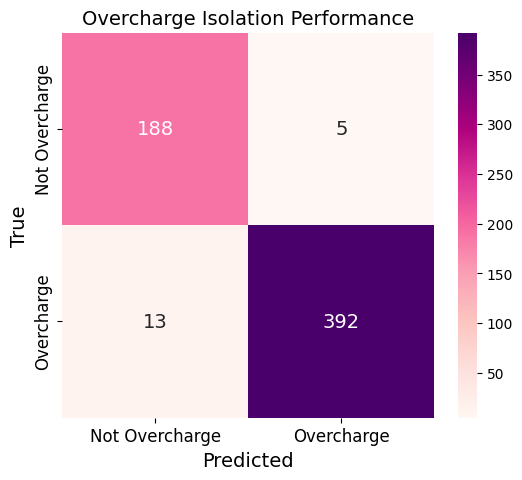

In [ ]:
cmap = 'RdPu' 

def print_and_plot_performance(y_true, y_pred, title):
    print(classification_report(y_true, y_pred, target_names=['Not Overcharge', 'Overcharge']))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                 xticklabels=['Not Overcharge', 'Overcharge'],
                 yticklabels=['Not Overcharge', 'Overcharge'],
                 annot_kws={"size": 14})
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('True', fontsize=14)
    plt.title(title, fontsize=14)
    plt.show()

def calculate_ocd_metric(original_sequence, reconstructed_sequence, mu=0, sigma=40):
    original_sequence = original_sequence.flatten()
    reconstructed_sequence = reconstructed_sequence.flatten()
    error_squared = np.square(original_sequence - reconstructed_sequence)
    re_standard = np.mean(error_squared)
    
    if re_standard == 0:
        return 0.0
    
    t = np.arange(len(original_sequence))
    weights = np.exp(-np.square(t - mu) / (2 * np.square(sigma)))
    re_weighted = np.mean(weights * error_squared)
    ocd_metric = re_weighted / re_standard
    return ocd_metric


def evaluate_isolation_performance(model, X_healthy, X_overcharge, X_low_temp, X_high_temp, X_overdischarge_temp, ocd_threshold=0.6, save=False):
    print("--- Evaluating Fault Isolation Performance ---")
    
    # Get reconstructions for all datasets
    recon_healthy = model.predict(filter_sg(X_healthy), verbose=0)
    recon_overcharge = model.predict(filter_sg(X_overcharge), verbose=0)
    recon_low_temp = model.predict(filter_sg(X_low_temp), verbose=0)
    recon_high_temp = model.predict(filter_sg(X_high_temp), verbose=0)
    recon_overdischarge_temp = model.predict(filter_sg(X_overdischarge_temp), verbose=0)
    
    # Calculate OCD metrics for every sample in each dataset
    ocd_healthy = [calculate_ocd_metric(X_healthy[i], recon_healthy[i]) for i in range(len(X_healthy))]
    ocd_overcharge = [calculate_ocd_metric(X_overcharge[i], recon_overcharge[i]) for i in range(len(X_overcharge))]
    ocd_low_temp = [calculate_ocd_metric(X_low_temp[i], recon_low_temp[i]) for i in range(len(X_low_temp))]
    ocd_high_temp = [calculate_ocd_metric(X_high_temp[i], recon_high_temp[i]) for i in range(len(X_high_temp))]
    ocd_overdischarge_temp = [calculate_ocd_metric(X_overdischarge_temp[i], recon_overdischarge_temp[i]) for i in range(len(X_overdischarge_temp))]

    all_data = (
        [('Healthy', v) for v in ocd_healthy] +
        [('Overcharge', v) for v in ocd_overcharge] +
        [('Low Temp Fault', v) for v in ocd_low_temp] +
        [('High Temp Fault', v) for v in ocd_high_temp] +
        [('Overdischarge Fault', v) for v in ocd_overdischarge_temp]
    )

    df_ocd = pd.DataFrame(all_data, columns=['Condition', 'OCD'])

    fig = px.box(df_ocd, x='Condition', y='OCD', color='Condition',
                title='Distribution of OCD Metric Across Fault Types',
                points= False)

    fig.update_layout(
        template="plotly",
        yaxis_title= dict(text="OCD Metric", font=dict(size=20)),
        xaxis_title= dict(text="Fault Conditions", font=dict(size=20)),
        xaxis=dict(tickfont=dict(size=16)),
        yaxis=dict(tickfont=dict(size=16)),
        title_font=dict(size=24), 
        showlegend=False
    )
       
    fig.add_annotation(
            xref='paper',
            yref='paper',
            x=1.0,
            y=1.12,
            text=f"OCD Threshold = {ocd_threshold}",
            showarrow=False,
            font=dict(color="red", size=18),
            align="right"
        )
    
    fig.add_hline(y=ocd_threshold, line_dash="dash", line_color="red") 

    if save:
        os.makedirs("Results", exist_ok=True)
        save_path = os.path.join("Results", "OCD_Threshold.jpg")
        fig.write_image(save_path,width=900,height=500,scale=8)  
    fig.show()
    
    print(f"\n--- Evaluating Isolation Rule: OCD > {ocd_threshold} ---")
    
    y_true_overcharge = np.ones(len(ocd_overcharge))
    y_true_other = np.zeros(len(ocd_healthy) + len(ocd_low_temp) + len(ocd_high_temp) + len(ocd_overdischarge_temp))
    y_true = np.concatenate([y_true_overcharge, y_true_other])
    
    all_ocd_metrics = np.concatenate([ocd_overcharge, ocd_healthy, ocd_low_temp, ocd_high_temp, ocd_overdischarge_temp])
    y_pred = (all_ocd_metrics > ocd_threshold).astype(int)
    
    print_and_plot_performance(y_true, y_pred, "Overcharge Isolation Performance")

X_overcharge_all = np.concatenate([X_anomaly_435, X_anomaly_450], axis=0)

evaluate_isolation_performance(
    model=model_base,
    X_healthy=X_valid,
    X_overcharge=X_overcharge_all,
    X_low_temp=X_low_temp_fault,
    X_high_temp=X_high_temp_fault,
    X_overdischarge_temp=X_overdischarge_fault,
    ocd_threshold=0.6,
    save = False

)
